#  E-Commerce Sales Intelligence Analysis
### Dataset: Olist Brazilian E-Commerce

**Author:** Mohamed Arsath A | B.Tech AI & Data Science  
**Dataset:** Olist Brazilian E-Commerce — Kaggle  
**Tools:** Python, Pandas, NumPy, Matplotlib, Seaborn, Sklearn  

###  Project Overview
This project analyzes **100,000+ real e-commerce orders** from Olist, Brazil's largest online marketplace.  
We explore sales trends, customer behavior, product performance, and build an **ML model to forecast future revenue**.

In [2]:
import os
import warnings
import pandas as pd        
import numpy as np  
import matplotlib.pyplot as plt          
import matplotlib.gridspec as gridspec   
import matplotlib.patches as mpatches  
import seaborn as sns    
from sklearn.ensemble import RandomForestRegressor   # ML model
from sklearn.linear_model import LinearRegression    # ML model
from sklearn.model_selection import train_test_split # split data
from sklearn.metrics import r2_score, mean_absolute_error  # evaluate  
warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')

## Cell 2: Load Real Data
We load all 7 CSV files from the Olist dataset.  

In [4]:
DATA='data/'
orders=pd.read_csv(DATA +'olist_orders_dataset.csv')
items =pd.read_csv(DATA + 'olist_order_items_dataset.csv')
products  = pd.read_csv(DATA + 'olist_products_dataset.csv')
customers = pd.read_csv(DATA + 'olist_customers_dataset.csv')
payments  = pd.read_csv(DATA + 'olist_order_payments_dataset.csv')
reviews   = pd.read_csv(DATA + 'olist_order_reviews_dataset.csv')
sellers   = pd.read_csv(DATA + 'olist_sellers_dataset.csv')
print('Dataset shapes (rows x columns):')
print(f' orders     :{orders.shape}')
print(f'  Items     : {items.shape}')
print(f'  Products  : {products.shape}')
print(f'  Customers : {customers.shape}')
print(f'  Payments  : {payments.shape}')
print(f'  Reviews   : {reviews.shape}')
print(f'  Sellers   : {sellers.shape}')

print('\n Orders table preview:')
orders.head()

Dataset shapes (rows x columns):
 orders     :(99441, 8)
  Items     : (112650, 7)
  Products  : (32951, 9)
  Customers : (99441, 5)
  Payments  : (103886, 5)
  Reviews   : (99224, 7)
  Sellers   : (3095, 4)

 Orders table preview:


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


##  Cell 3: Explore Raw Data
Before cleaning, always explore the data first.  
Check for missing values, data types, and basic stats.

In [5]:
print(orders.isnull().sum())
print(orders.dtypes)
print(orders['order_status'].value_counts())

order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
order_estimated_delivery_date       0
dtype: int64
order_id                         object
customer_id                      object
order_status                     object
order_purchase_timestamp         object
order_approved_at                object
order_delivered_carrier_date     object
order_delivered_customer_date    object
order_estimated_delivery_date    object
dtype: object
order_status
delivered      96478
shipped         1107
canceled         625
unavailable      609
invoiced         314
processing       301
created            5
approved           2
Name: count, dtype: int64


In [20]:
orders.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


## Cell 4: Data Cleaning

In [6]:
# Convert date columns to datetime
data_cols=[
'order_purchase_timestamp',
'order_approved_at',
'order_delivered_carrier_date',
'order_delivered_customer_date',
'order_estimated_delivery_date'

]

for col in data_cols:
    orders[col]=pd.to_datetime(orders[col],errors='coerce')
print(f'order{len(orders):,}')

# Keep only delivered orders
orders_clean= orders[orders['order_status']== 'delivered'].copy()
print(f'delivered {len(orders_clean):,}')
# Remove rows with missing dates
orders_clean=orders_clean.dropna(subset=[
    'order_purchase_timestamp',
    'order_delivered_carrier_date'
    ])
print(f'remove null value :{len(orders_clean):,}')
# Calculate delivery time in days
orders_clean['delivery_days']= (orders_clean['order_delivered_customer_date'] -
orders_clean['order_purchase_timestamp']).dt.days

# Remove impossible delivery times
orders_clean=orders_clean[ (orders_clean['delivery_days'] > 0) & (orders_clean['delivery_days']<120)]
print(f'Final clean orders: {len(orders_clean):,}')

print('\nDelivery time summary:')
print(orders_clean['delivery_days'].describe().round(1))




order99,441
delivered 96,478
remove null value :96,476
Final clean orders: 96,413

Delivery time summary:
count    96413.0
mean        12.0
std          9.0
min          1.0
25%          6.0
50%         10.0
75%         15.0
max        118.0
Name: delivery_days, dtype: float64


In [6]:
payments.head()

,order_id,payment_sequential,payment_type,payment_installments,payment_value
0,b81ef226f3fe1789b1e8b2acac839d17,1,credit_card,8,99.33
1,a9810da82917af2d9aefd1278f1dcfa0,1,credit_card,1,24.39
2,25e8ea4e93396b6fa0d3dd708e76c1bd,1,credit_card,1,65.71
3,ba78997921bbcdc1373bb41e913ab953,1,credit_card,8,107.78
4,42fdf880ba16b47b59251dd489d4441a,1,credit_card,2,128.45


## Cell 5: Merge All Tables

In [7]:
# Aggregate payments per order
pay_agg=payments.groupby('order_id').agg(
     total_payment =('payment_value','sum'),
     payment_type =('payment_type','first'),
     installments =('payment_installments','max')

).reset_index()

# Aggregate reviews per order
rev_agg=reviews.groupby('order_id').agg(
    review_score = ('review_score','mean')
).reset_index()

# Aggregate items per order
items_agg = items.groupby('order_id').agg(
    total_items   = ('order_item_id', 'count'),
    total_price   = ('price', 'sum'),
    total_freight = ('freight_value', 'sum'),
    product_id    = ('product_id', 'first')
).reset_index()
# Merge all tables
df=orders_clean.merge(pay_agg, on='order_id',how='left')
df = df.merge(rev_agg,            on='order_id', how='left')
df = df.merge(items_agg,          on='order_id', how='left')
df = df.merge(
    customers[['customer_id', 'customer_state']],
    on='customer_id', how='left')
df = df.merge(
    products[['product_id', 'product_category_name']],
    on='product_id', how='left'
)

# Fill missing values
df['review_score']          = df['review_score'].fillna(df['review_score'].median())
df['product_category_name'] = df['product_category_name'].fillna('unknown')
df['payment_type']          = df['payment_type'].fillna('unknown')
# Extract date features
df['year']       = df['order_purchase_timestamp'].dt.year
df['month']      = df['order_purchase_timestamp'].dt.month
df['month_name'] = df['order_purchase_timestamp'].dt.strftime('%b')
df['quarter']    = df['order_purchase_timestamp'].dt.quarter
df['dayofweek']  = df['order_purchase_timestamp'].dt.day_name()

# Keep 2017-2018
df = df[df['year'].isin([2017, 2018])]

print(f'Master dataset: {df.shape}')
print(f'Date range: {df["order_purchase_timestamp"].min().date()}',
      f'to {df["order_purchase_timestamp"].max().date()}')
df.head()








Master dataset: (96146, 24)
Date range: 2017-01-05 to 2018-08-29


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,delivery_days,total_payment,...,total_price,total_freight,product_id,customer_state,product_category_name,year,month,month_name,quarter,dayofweek
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,8.0,38.71,...,29.99,8.72,87285b34884572647811a353c7ac498a,SP,utilidades_domesticas,2017,10,Oct,4,Monday
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,13.0,141.46,...,118.70,22.76,595fac2a385ac33a80bd5114aec74eb8,BA,perfumaria,2018,7,Jul,3,Tuesday
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,9.0,179.12,...,159.90,19.22,aa4383b373c6aca5d8797843e5594415,GO,automotivo,2018,8,Aug,3,Wednesday
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,13.0,72.20,...,45.00,27.20,d0b61bfb1de832b15ba9d266ca96e5b0,RN,pet_shop,2017,11,Nov,4,Saturday
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,2.0,28.62,...,19.90,8.72,65266b2da20d04dbe00c5c2d3bb7859e,SP,papelaria,2018,2,Feb,1,Tuesday


## Cell 6: Key Business Statistics

In [8]:
total_revenue  = df['total_payment'].sum()
total_orders   = len(df)
avg_order      = df['total_payment'].mean()
avg_review     = df['review_score'].mean()
avg_delivery   = df['delivery_days'].mean()
total_products = df['product_id'].nunique()
total_customers= df['customer_id'].nunique()

print('=' * 45)
print('   KEY BUSINESS METRICS')
print('=' * 45)
print(f'  Total Revenue     : R$ {total_revenue:>12,.2f}')
print(f'  Total Orders      : {total_orders:>15,}')
print(f'  Total Customers   : {total_customers:>15,}')
print(f'  Unique Products   : {total_products:>15,}')
print(f'  Avg Order Value   : R$ {avg_order:>12,.2f}')
print(f'  Avg Review Score  : {avg_review:>14.2f} / 5')
print(f'  Avg Delivery Days : {avg_delivery:>14.1f} days')
print('=' * 45)

   KEY BUSINESS METRICS
  Total Revenue     : R$ 15,359,592.50
  Total Orders      :          96,146
  Total Customers   :          96,146
  Unique Products   :          31,015
  Avg Order Value   : R$       159.75
  Avg Review Score  :           4.16 / 5
  Avg Delivery Days :           12.0 days


## Cell 7: Chart 1 — Monthly Revenue Trend

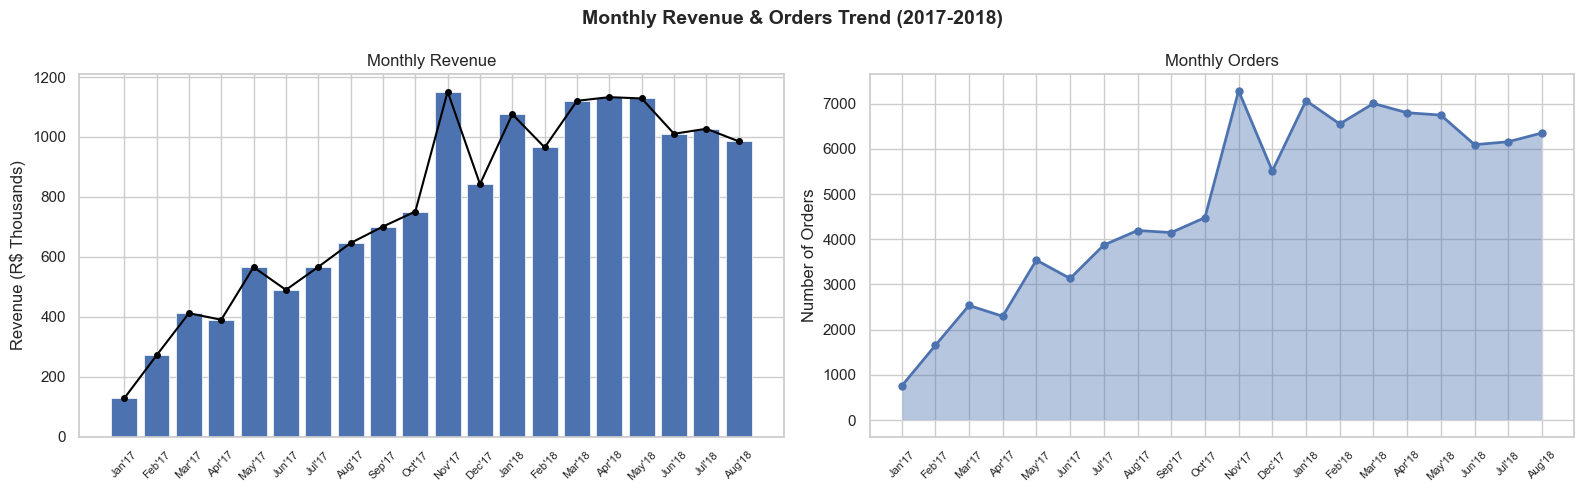

Chart 1 saved!


In [9]:
monthly = df.groupby(['year', 'month']).agg(
    Revenue = ('total_payment', 'sum'),
    Orders  = ('order_id', 'count')
).reset_index().sort_values(['year', 'month'])

monthly['label'] = (
    monthly['month'].apply(
        lambda x: pd.Timestamp(f'2017-{x:02d}-01').strftime('%b')
    ) + "'" + monthly['year'].astype(str).str[-2:]
)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('Monthly Revenue & Orders Trend (2017-2018)',
             fontsize=14, fontweight='bold')

# Left: Revenue
ax = axes[0]
ax.bar(range(len(monthly)), monthly['Revenue']/1e3,
       edgecolor='white', linewidth=0.5)
ax.plot(range(len(monthly)), monthly['Revenue']/1e3,
        color='black', linewidth=1.5,
        marker='o', markersize=4, zorder=5)
ax.set_xticks(range(len(monthly)))
ax.set_xticklabels(monthly['label'], rotation=45, fontsize=8)
ax.set_ylabel('Revenue (R$ Thousands)')
ax.set_title('Monthly Revenue')

# Right: Orders
ax = axes[1]
ax.fill_between(range(len(monthly)),
                monthly['Orders'], alpha=0.4)
ax.plot(range(len(monthly)), monthly['Orders'],
        linewidth=2, marker='o', markersize=5)
ax.set_xticks(range(len(monthly)))
ax.set_xticklabels(monthly['label'], rotation=45, fontsize=8)
ax.set_ylabel('Number of Orders')
ax.set_title('Monthly Orders')

plt.tight_layout()
plt.savefig('charts/chart1_monthly_trends.png',
            dpi=150, bbox_inches='tight')
plt.show()
print('Chart 1 saved!')

## Cell 8: Chart 2 — Top Product Categories

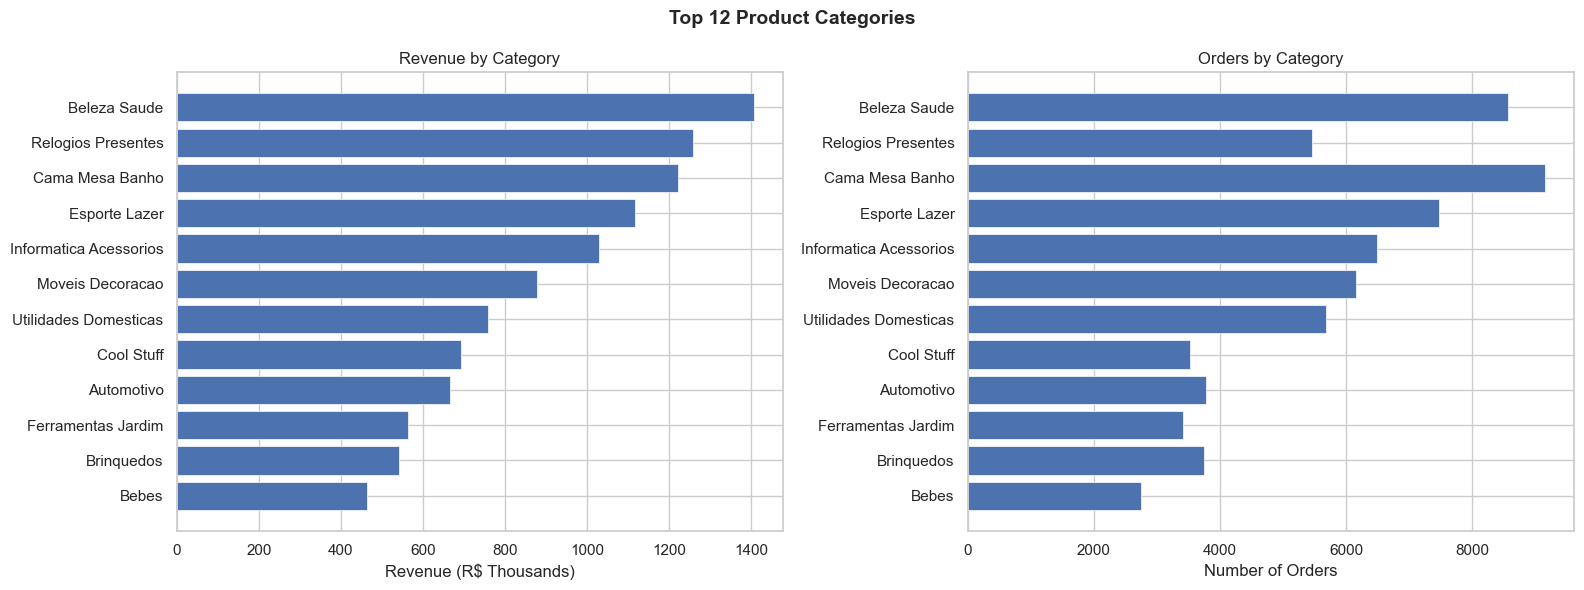

Chart 2 saved!


In [13]:
cat_stats = df.groupby('product_category_name').agg(
    Revenue    = ('total_payment', 'sum'),
    Orders     = ('order_id', 'count'),
    Avg_Review = ('review_score', 'mean')
).reset_index().sort_values('Revenue', ascending=False).head(12)

cat_stats['product_category_name'] = (
    cat_stats['product_category_name']
    .str.replace('_', ' ').str.title()
)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Top 12 Product Categories',
             fontsize=14, fontweight='bold')

# Left: Revenue
ax = axes[0]
ax.barh(
    cat_stats['product_category_name'],
    cat_stats['Revenue'] / 1e3,
    edgecolor='white', linewidth=0.5
)
ax.set_xlabel('Revenue (R$ Thousands)')
ax.set_title('Revenue by Category')
ax.invert_yaxis()

# Right: Orders
ax = axes[1]
ax.barh(
    cat_stats['product_category_name'],
    cat_stats['Orders'],
    edgecolor='white', linewidth=0.5
)
ax.set_xlabel('Number of Orders')
ax.set_title('Orders by Category')
ax.invert_yaxis()

plt.tight_layout()
plt.savefig('charts/chart2_categories.png',
            dpi=150, bbox_inches='tight')
plt.show()
print('Chart 2 saved!')





## Cell 9: Chart 3 — State & Payment Analysis

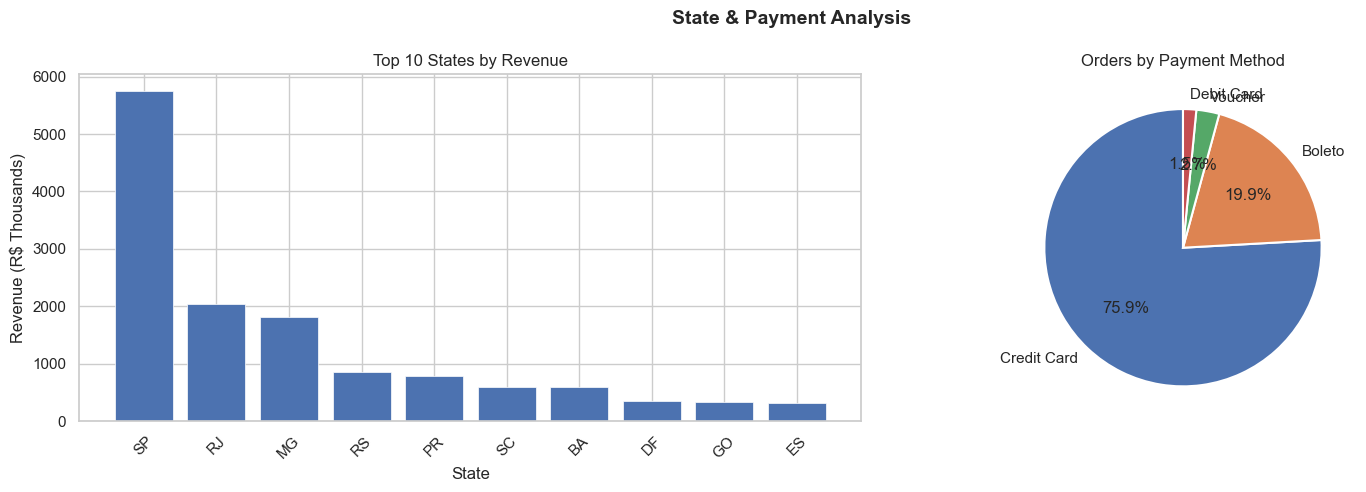

Chart 3 saved!


In [14]:
state_stats = df.groupby('customer_state').agg(
    Revenue = ('total_payment', 'sum'),
    Orders  = ('order_id', 'count')
).reset_index().sort_values('Revenue', ascending=False).head(10)

pay_stats = df.groupby('payment_type').agg(
    Revenue = ('total_payment', 'sum'),
    Orders  = ('order_id', 'count')
).reset_index().sort_values('Orders', ascending=False)
pay_stats['payment_type'] = (
    pay_stats['payment_type']
    .str.replace('_', ' ').str.title()
)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('State & Payment Analysis',
             fontsize=14, fontweight='bold')

# Left: States
ax = axes[0]
ax.bar(
    state_stats['customer_state'],
    state_stats['Revenue'] / 1e3,
    edgecolor='white', linewidth=0.5
)
ax.set_ylabel('Revenue (R$ Thousands)')
ax.set_xlabel('State')
ax.set_title('Top 10 States by Revenue')
ax.tick_params(axis='x', rotation=45)

# Right: Payment pie
ax = axes[1]
ax.pie(
    pay_stats['Orders'],
    labels=pay_stats['payment_type'],
    autopct='%1.1f%%',
    startangle=90,
    wedgeprops=dict(edgecolor='white', linewidth=1.5)
)
ax.set_title('Orders by Payment Method')

plt.tight_layout()
plt.savefig('charts/chart3_state_payment.png',
            dpi=150, bbox_inches='tight')
plt.show()
print('Chart 3 saved!')

## Cell 10: Chart 4 — Delivery & Review Analysis

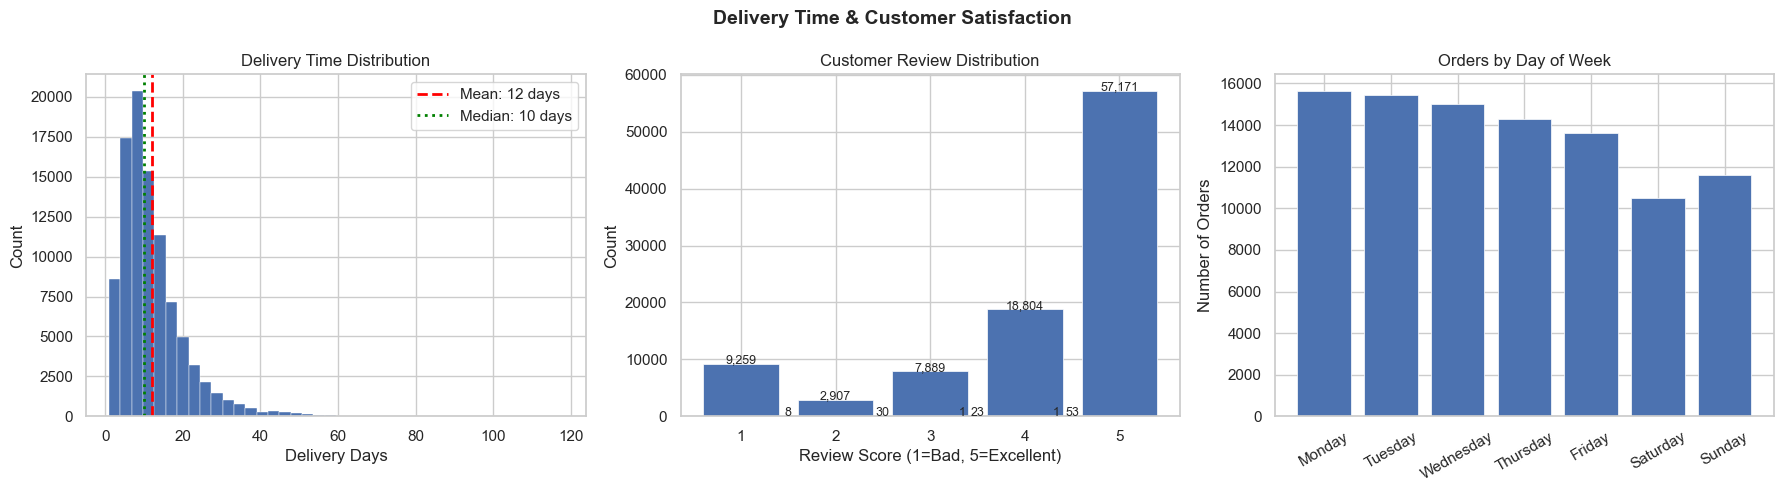

Chart 4 saved!


In [15]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Delivery Time & Customer Satisfaction',
             fontsize=14, fontweight='bold')

# Left: Delivery histogram
ax = axes[0]
ax.hist(df['delivery_days'].dropna(), bins=40,
        edgecolor='white', linewidth=0.3)
ax.axvline(df['delivery_days'].mean(),
           color='red', linewidth=2, linestyle='--',
           label=f"Mean: {df['delivery_days'].mean():.0f} days")
ax.axvline(df['delivery_days'].median(),
           color='green', linewidth=2, linestyle=':',
           label=f"Median: {df['delivery_days'].median():.0f} days")
ax.set_xlabel('Delivery Days')
ax.set_ylabel('Count')
ax.set_title('Delivery Time Distribution')
ax.legend()

# Middle: Review scores
ax = axes[1]
review_counts = df['review_score'].value_counts().sort_index()
ax.bar(review_counts.index, review_counts.values,
       edgecolor='white', linewidth=0.5)
for i, val in zip(review_counts.index, review_counts.values):
    ax.text(i, val + 50, f'{val:,}',
            ha='center', fontsize=9)
ax.set_xlabel('Review Score (1=Bad, 5=Excellent)')
ax.set_ylabel('Count')
ax.set_title('Customer Review Distribution')

# Right: Orders by day
ax = axes[2]
day_order = ['Monday','Tuesday','Wednesday',
             'Thursday','Friday','Saturday','Sunday']
day_data  = df.groupby('dayofweek')['order_id'].count().reindex(day_order)
ax.bar(day_data.index, day_data.values,
       edgecolor='white', linewidth=0.5)
ax.set_ylabel('Number of Orders')
ax.set_title('Orders by Day of Week')
ax.tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.savefig('charts/chart4_delivery_reviews.png',
            dpi=150, bbox_inches='tight')
plt.show()
print('Chart 4 saved!')

## Cell 11: Chart 5 — Revenue Heatmap

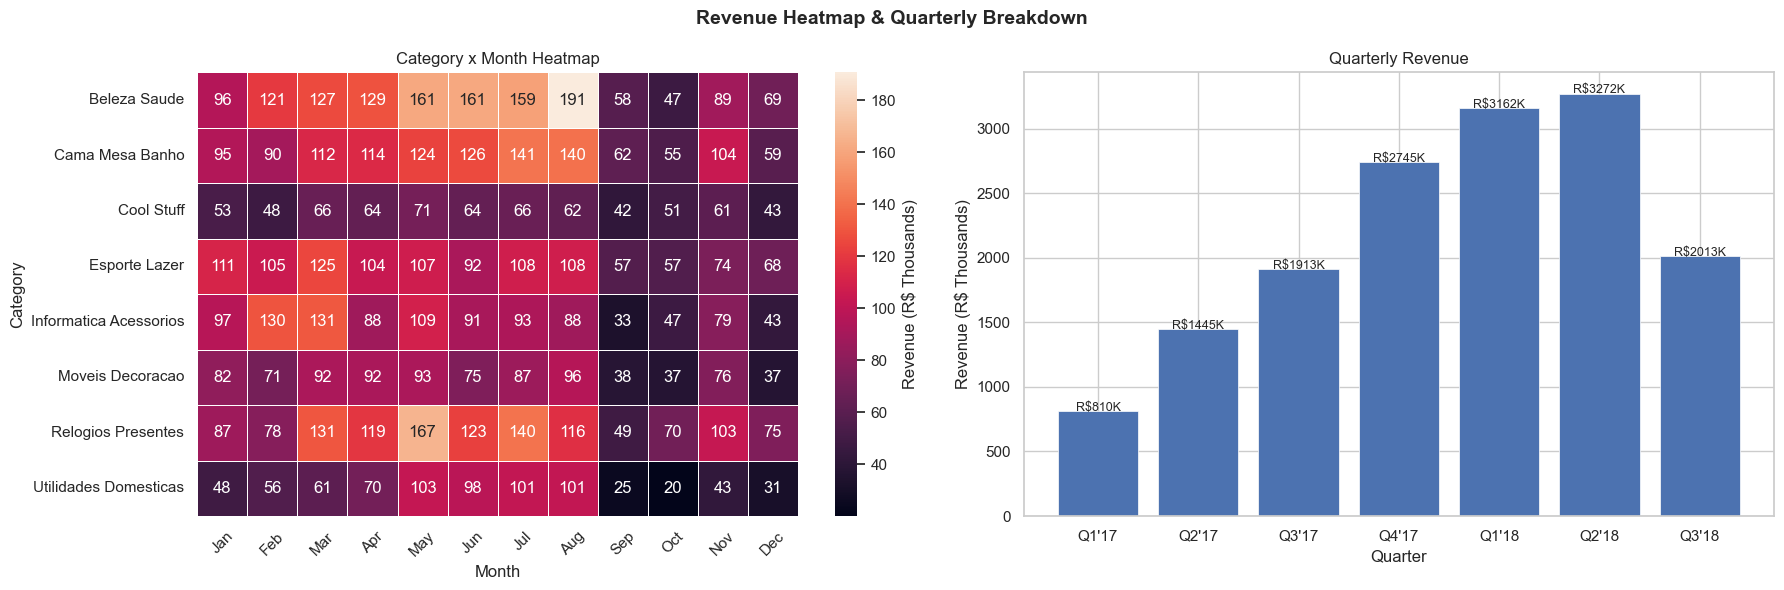

Chart 5 saved!


In [16]:
df['cat_clean'] = (
    df['product_category_name']
    .str.replace('_', ' ').str.title()
)

top_cats = cat_stats['product_category_name'].head(8).tolist()
df_top   = df[df['cat_clean'].isin(top_cats)]

pivot = df_top.pivot_table(
    values  = 'total_payment',
    index   = 'cat_clean',
    columns = 'month',
    aggfunc = 'sum'
)
pivot.columns = [
    pd.Timestamp(f'2017-{m:02d}-01').strftime('%b')
    for m in pivot.columns
]

fig, axes = plt.subplots(1, 2, figsize=(18, 6))
fig.suptitle('Revenue Heatmap & Quarterly Breakdown',
             fontsize=14, fontweight='bold')

# Left: Heatmap
ax = axes[0]
sns.heatmap(
    pivot/1e3, annot=True, fmt='.0f', ax=ax,
    linewidths=0.5, linecolor='white',
    cbar_kws={'label': 'Revenue (R$ Thousands)'}
)
ax.set_xlabel('Month')
ax.set_ylabel('Category')
ax.set_title('Category x Month Heatmap')
ax.tick_params(axis='x', rotation=45)

# Right: Quarterly
ax = axes[1]
q_stats = df.groupby(['year', 'quarter']).agg(
    Revenue = ('total_payment', 'sum')
).reset_index()
q_stats['label'] = (
    'Q' + q_stats['quarter'].astype(str) +
    "'" + q_stats['year'].astype(str).str[-2:]
)
ax.bar(q_stats['label'], q_stats['Revenue']/1e3,
       edgecolor='white', linewidth=0.5)
for i, val in enumerate(q_stats['Revenue']/1e3):
    ax.text(i, val + 0.5, f'R${val:.0f}K',
            ha='center', fontsize=9)
ax.set_ylabel('Revenue (R$ Thousands)')
ax.set_xlabel('Quarter')
ax.set_title('Quarterly Revenue')

plt.tight_layout()
plt.savefig('charts/chart5_heatmap.png',
            dpi=150, bbox_inches='tight')
plt.show()
print('Chart 5 saved!')

## Cell 12: Chart 6 — ML Sales Forecasting
Train Random Forest and Linear Regression to predict future revenue.

In [17]:
# Prepare ML data
ml_data = df.groupby(['year', 'month']).agg(
    Revenue      = ('total_payment', 'sum'),
    Orders       = ('order_id', 'count'),
    Avg_Review   = ('review_score', 'mean'),
    Avg_Delivery = ('delivery_days', 'mean')
).reset_index()

ml_data['month_num'] = (
    (ml_data['year'] - 2017) * 12 + ml_data['month']
)

X = ml_data[['month_num','Orders','Avg_Review','Avg_Delivery']]
y = ml_data['Revenue']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42
)

# Random Forest
rf = RandomForestRegressor(n_estimators=200, random_state=42)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X)

# Linear Regression
lr = LinearRegression()
lr.fit(X_train, y_train)
lr_pred = lr.predict(X)

rf_r2  = r2_score(y, rf_pred)
lr_r2  = r2_score(y, lr_pred)
rf_mae = mean_absolute_error(y, rf_pred)

print(f'Random Forest  R2 : {rf_r2:.3f}')
print(f'Linear Reg     R2 : {lr_r2:.3f}')
print(f'Random Forest MAE : R${rf_mae:,.0f}')

# Forecast next 3 months
last_month = ml_data['month_num'].max()
future = pd.DataFrame({
    'month_num':    [last_month+1, last_month+2, last_month+3],
    'Orders':       [ml_data['Orders'].mean()*1.05]*3,
    'Avg_Review':   [ml_data['Avg_Review'].mean()]*3,
    'Avg_Delivery': [ml_data['Avg_Delivery'].mean()]*3,
})
future_rev = rf.predict(future)

print(f'\nForecast Month+1 : R${future_rev[0]:,.0f}')
print(f'Forecast Month+2 : R${future_rev[1]:,.0f}')
print(f'Forecast Month+3 : R${future_rev[2]:,.0f}')

Random Forest  R2 : 0.921
Linear Reg     R2 : 0.988
Random Forest MAE : R$50,357

Forecast Month+1 : R$880,123
Forecast Month+2 : R$880,123
Forecast Month+3 : R$880,123


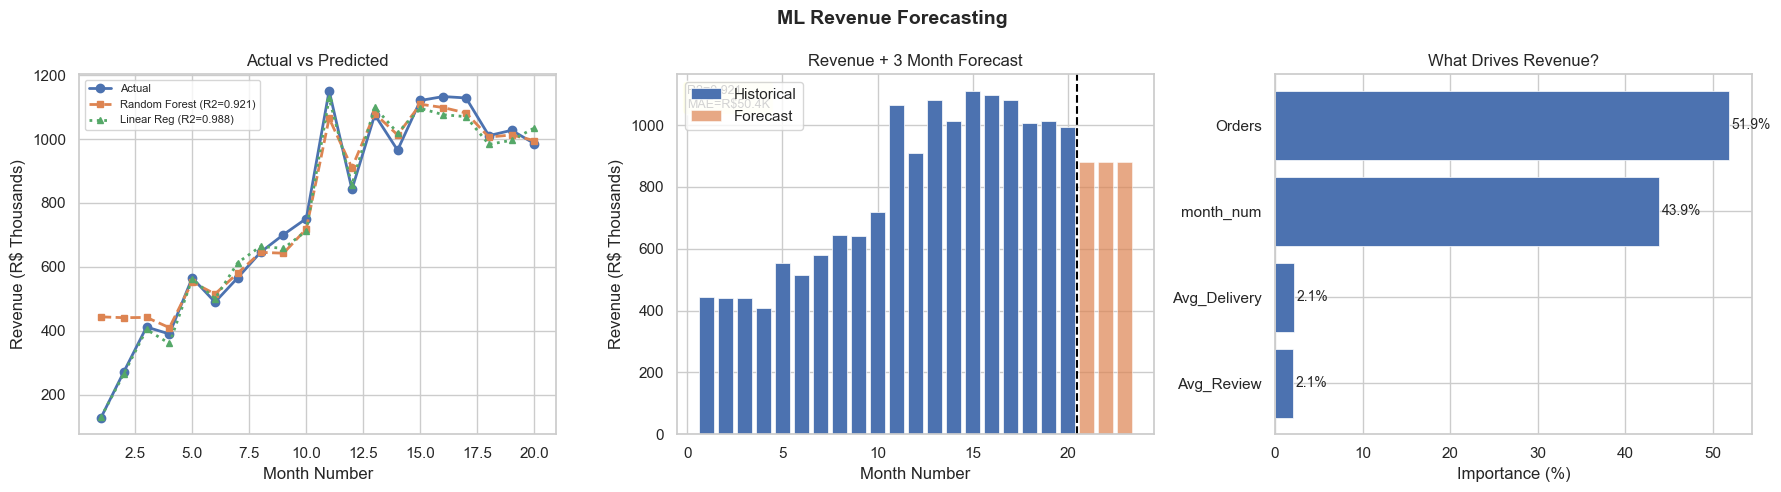

Chart 6 saved!


In [18]:
feat_imp = pd.Series(
    rf.feature_importances_, index=X.columns
).sort_values(ascending=True)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('ML Revenue Forecasting',
             fontsize=14, fontweight='bold')

# Left: Actual vs Predicted
ax = axes[0]
ax.plot(ml_data['month_num'], y/1e3,
        'o-', linewidth=2, markersize=6, label='Actual')
ax.plot(ml_data['month_num'], rf_pred/1e3,
        's--', linewidth=2, markersize=5,
        label=f'Random Forest (R2={rf_r2:.3f})')
ax.plot(ml_data['month_num'], lr_pred/1e3,
        '^:', linewidth=2, markersize=5,
        label=f'Linear Reg (R2={lr_r2:.3f})')
ax.set_xlabel('Month Number')
ax.set_ylabel('Revenue (R$ Thousands)')
ax.set_title('Actual vs Predicted')
ax.legend(fontsize=8)

# Middle: Forecast
ax = axes[1]
all_months = list(ml_data['month_num']) + [
    last_month+1, last_month+2, last_month+3
]
all_rev = list(rf_pred/1e3) + list(future_rev/1e3)
ax.bar(all_months[:len(ml_data)],
       all_rev[:len(ml_data)],
       edgecolor='white', linewidth=0.5, label='Historical')
ax.bar(all_months[len(ml_data):],
       all_rev[len(ml_data):],
       edgecolor='white', linewidth=0.5,
       alpha=0.7, label='Forecast')
ax.axvline(last_month + 0.5, color='black',
           linestyle='--', linewidth=1.5)
ax.set_xlabel('Month Number')
ax.set_ylabel('Revenue (R$ Thousands)')
ax.set_title('Revenue + 3 Month Forecast')
ax.legend()
ax.text(0.02, 0.97,
        f'R2={rf_r2:.3f}\nMAE=R${rf_mae/1e3:.1f}K',
        transform=ax.transAxes, fontsize=9, va='top',
        bbox=dict(boxstyle='round',
                  facecolor='lightyellow', alpha=0.8))

# Right: Feature importance
ax = axes[2]
ax.barh(feat_imp.index, feat_imp.values*100,
        edgecolor='white', linewidth=0.5)
for i, val in enumerate(feat_imp.values*100):
    ax.text(val + 0.3, i, f'{val:.1f}%',
            va='center', fontsize=10)
ax.set_xlabel('Importance (%)')
ax.set_title('What Drives Revenue?')

plt.tight_layout()
plt.savefig('charts/chart6_ml_forecast.png',
            dpi=150, bbox_inches='tight')
plt.show()
print('Chart 6 saved!')

In [19]:
print('=' * 55)
print('   KEY INSIGHTS — OLIST E-COMMERCE ANALYSIS')
print('=' * 55)
print(f'\n1. REVENUE')
print(f'   Total : R${total_revenue:,.0f}')
print(f'   Avg order value : R${avg_order:.2f}')
print(f'\n2. TOP CATEGORY')
print(f'   {cat_stats.iloc[0]["product_category_name"]}')
print(f'\n3. TOP STATE')
print(f'   {state_stats.iloc[0]["customer_state"]}')
print(f'\n4. PAYMENT')
print(f'   {pay_stats.iloc[0]["payment_type"]}')
print(f'\n5. DELIVERY')
print(f'   Average : {avg_delivery:.1f} days')
print(f'\n6. SATISFACTION')
print(f'   Avg review : {avg_review:.2f} / 5.0')
print(f'\n7. ML MODEL')
print(f'   Random Forest R2 : {rf_r2:.3f}')
print(f'   Explains {rf_r2*100:.1f}% of revenue variation')
print(f'\n8. FORECAST')
print(f'   Next month : R${future_rev[0]:,.0f}')
print('=' * 55)
print('\nAll charts saved in charts/ folder!')
print('Ready for GitHub and LinkedIn!')

   KEY INSIGHTS — OLIST E-COMMERCE ANALYSIS

1. REVENUE
   Total : R$15,359,592
   Avg order value : R$159.75

2. TOP CATEGORY
   Beleza Saude

3. TOP STATE
   SP

4. PAYMENT
   Credit Card

5. DELIVERY
   Average : 12.0 days

6. SATISFACTION
   Avg review : 4.16 / 5.0

7. ML MODEL
   Random Forest R2 : 0.921
   Explains 92.1% of revenue variation

8. FORECAST
   Next month : R$880,123

All charts saved in charts/ folder!
Ready for GitHub and LinkedIn!


---
## Project Complete!

### What We Did:
- Loaded and cleaned 100,000+ real orders from 7 CSV files
- Merged multiple tables using Pandas
- Built 6 professional visualizations
- Trained Random Forest ML model
- Forecasted 3 months of future revenue

### Skills Used:
`Python` `Pandas` `NumPy` `Matplotlib` `Seaborn` `Sklearn` `Data Cleaning` `EDA` `Machine Learning` `Forecasting`
---
*B.Tech AI & Data Science | Portfolio Project*